## Hotel Recommendation System

### Problem Statement
The objective is to build a recommendation system that suggests hotels to users based on their past preferences and booking history.

### Business Use Case
Personalized hotel recommendations improve user experience, increase engagement, and boost booking conversions in travel platforms.

### Dataset Description
- Users dataset: contains user demographics
- Hotels dataset: contains hotel booking details such as place, price, and stay duration

### GitHub Repository
[Voyage-Analytics-MLops](https://github.com/Aks18had/Voyage-Analytics-MLops)

In [1]:
from google.colab import drive # Mounting the drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os # Giving the exact the path to extract the data

base_path = '/content/drive/MyDrive/Voyage-Analytics-MLops'
data_path = os.path.join(base_path, 'data')

print(os.listdir(data_path))

['flights.csv', 'users.csv', 'hotels.csv']


In [5]:
import pandas as pd # Loading the dataset

users = pd.read_csv(os.path.join(data_path, 'users.csv'))
hotels = pd.read_csv(os.path.join(data_path, 'hotels.csv'))

users.head()
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [6]:
print("Users columns:", users.columns)
print("Hotels columns:", hotels.columns)

Users columns: Index(['code', 'company', 'name', 'gender', 'age'], dtype='object')
Hotels columns: Index(['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total',
       'date'],
      dtype='object')


In [7]:
users.rename(columns={'code': 'userCode'}, inplace=True) # Reanaming the code colum to usercode for getting it merge

In [8]:
data = pd.merge(users, hotels, on='userCode') # Merging the data
data.head()

,userCode,company,name_x,gender,age,travelCode,name_y,place,days,price,total,date
0,0,4You,Roy Braun,male,21,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,0,4You,Roy Braun,male,21,2,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,0,4You,Roy Braun,male,21,7,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,0,4You,Roy Braun,male,21,11,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,0,4You,Roy Braun,male,21,13,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


### Data Integration Challenge

During data merging, a mismatch in column names was identified where the Users dataset used 'code' while the Hotels dataset used 'userCode'.

This was resolved by renaming the column to ensure consistency across datasets.

In [9]:
data = data[['userCode', 'place', 'price', 'days']] # Data cleaning

data.head()

,userCode,place,price,days
0,0,Florianopolis (SC),313.02,4
1,0,Salvador (BH),263.41,2
2,0,Salvador (BH),263.41,3
3,0,Salvador (BH),263.41,4
4,0,Florianopolis (SC),313.02,1


### Data Cleaning

After merging datasets, only relevant features were selected for building the recommendation system.

Irrelevant columns such as user name and hotel name were removed to simplify the model.

In [11]:
data.info() # Understanding the data
data[['place', 'price', 'days']].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   userCode  40552 non-null  int64  
 1   place     40552 non-null  object 
 2   price     40552 non-null  float64
 3   days      40552 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.2+ MB


,price,days
count,40552.000000,40552.000000
mean,214.439554,2.499679
std,76.742305,1.119326
min,60.390000,1.000000
25%,165.990000,1.000000
50%,242.880000,2.000000
75%,263.410000,4.000000
max,313.020000,4.000000


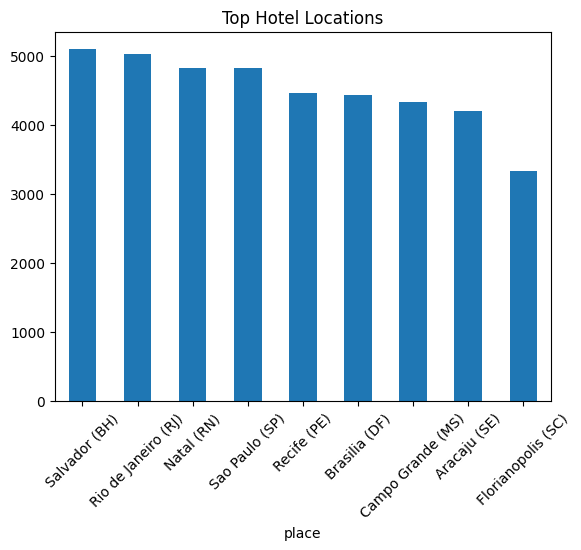

In [12]:
import matplotlib.pyplot as plt # Top hotel visuals Bar Charts

data['place'].value_counts().head(10).plot(kind='bar')
plt.title("Top Hotel Locations")
plt.xticks(rotation=45)
plt.show()

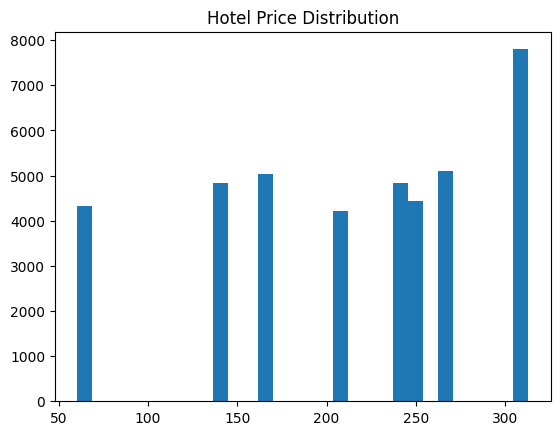

In [13]:
plt.hist(data['price'], bins=30) # Histogram price distribuation
plt.title("Hotel Price Distribution")
plt.show()

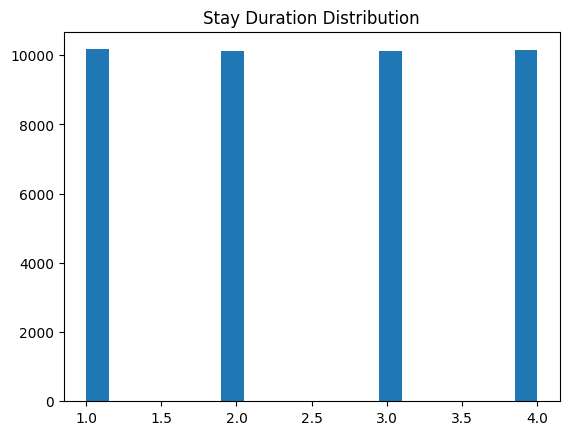

In [14]:
plt.hist(data['days'], bins=20) # Stay distribuation
plt.title("Stay Duration Distribution")
plt.show()

### Observations

- Certain locations are more popular among users.
- Hotel prices vary across locations and bookings.
- Stay duration provides insight into user behavior.

In [15]:
data = data[['userCode', 'place', 'price', 'days']] # Data cleaning and here droping the coloum

data.dropna(inplace=True)

In [16]:
user_history = data.groupby('userCode')['place'].apply(list)
user_history.head()

,place
userCode,
0,"[Florianopolis (SC), Salvador (BH), Salvador (..."
1,"[Sao Paulo (SP), Brasilia (DF)]"
2,"[Rio de Janeiro (RJ), Campo Grande (MS), Araca..."
3,"[Florianopolis (SC), Florianopolis (SC), Flori..."
4,"[Recife (PE), Recife (PE), Recife (PE), Salvad..."


In [17]:
def recommend_hotels(user_id, data, top_n=5): # To show top 5 hotels

    if user_id not in data['userCode'].values:
        return "User not found"

    # user history
    user_places = data[data['userCode'] == user_id]['place']

    # similar hotels
    similar_hotels = data[data['place'].isin(user_places)]

    # remove duplicates + sort by price
    recommendations = (
        similar_hotels
        .drop_duplicates('place')
        .sort_values(by='price')
        .head(top_n)
    )

    return recommendations[['place', 'price']]

In [22]:
recommend_hotels(0, data)

,place,price
13,Campo Grande (MS),60.39
8,Sao Paulo (SP),139.10
22,Rio de Janeiro (RJ),165.99
6,Aracaju (SE),208.04
5,Natal (RN),242.88


### Recommendation Approach

A content-based recommendation system was implemented using user booking history.

Hotels previously visited by the user were identified, and similar hotels were recommended based on location and price.
### Real-world Relevance

In production systems, more advanced recommendation techniques such as collaborative filtering and hybrid models can be used to improve accuracy.

In [23]:
data['place'].value_counts().head(10)

,count
place,
Salvador (BH),5094
Rio de Janeiro (RJ),5029
Natal (RN),4829
Sao Paulo (SP),4828
Recife (PE),4467
Brasilia (DF),4437
Campo Grande (MS),4333
Aracaju (SE),4205
Florianopolis (SC),3330


### Conclusion

A hotel recommendation system was successfully built using user booking data.

This demonstrates how historical user behavior can be leveraged to provide personalized recommendations in travel platforms.